# AAV5 -- `ProtocolV3` sur la phase de viabilite (D=1e6, profondeur calibree)

Question : sur la population `viab` validee (`AAV5_organoides_sorted.csv`, filtre `[10,500]` sur
`compte_plasmide`, confirme bimodal et non-artefactuel dans `AAV5_viab_sorting.ipynb`), le protocole
mecaniste `ProtocolV3` reproduit-il la vraie forme de `log2_enrichissement_virus_sur_plasmide`
(y compris la bimodalite fit/non-fit) quand la profondeur de sequencage `D` est calibree pour
matcher le ratio reads/variant reel, au lieu d'un `D=1e8` repris tel quel d'AAV9 ?

**Calibration de `D`** (demande explicite) : sur le CSV brut (5 595 543 variants), le total de
reads reels est ~1.16e8 (plasmide) / ~1.76e8 (virus), soit ~21-31 reads/variant ; sur le CSV `viab`
trie (3 822 400 variants), ~27-39 reads/variant. Ce notebook sous-echantillonne `N_SIM=50 000`
variants -- pour garder le meme ratio reads/variant a cette echelle reduite, `D=1e6` donne
`D/d0=20` reads/variant, le meme ordre de grandeur que le reel.

**Choix de ce run** :
- Memes variants que le CSV : sous-echantillon de `AAV5_organoides_sorted.csv`, PAS un pool
  synthetique.
- Librairie initiale `lambda0` calibree sur le VRAI `compte_plasmide` de chaque variant (pas un
  proxy comme dans `AAV5_SEL_fitting_protocol_org2org3.ipynb`) : `lambda0(s) = compte_plasmide(s) *
  dilution_factor`, pour que `sample_sequences()` (Binomial(lambda0, p=1/dilution_factor)) retombe
  en esperance exactement sur `compte_plasmide(s)`. Le CSV `viab` bornant deja `compte_plasmide`
  a `[10,500]`, aucune winsorisation n'est necessaire ici (contrairement au notebook org2org3, ou
  `avg(org2,org3)` non borne concentrait 13% de la masse sur un seul variant).
- Phase de SELECTIVITE non modelisee ici -- `F_sel=J_sel=0` (`ProtocolV3.selectivity()` tourne
  quand meme via `loop_DE()`, mais son resultat est ignore ; sigmoid(0)=0.5 ne provoque aucune
  erreur numerique).
- Autres parametres repris tels quels du point de fonctionnement "classique" deja etabli pour AAV5
  (`AAV5_SEL_fitting_protocol.ipynb`/`AAV5_SEL_fitting_protocol_org2org3.ipynb`) : `rho=1e-3`,
  `mu=50`, `T_viab=1/ln(2)`, `noise_viab=0.5`, `dilution_factor=1e5` -- SEUL `D` change ici.
- Poids : `aav5_F_viab_potts_sorted_unreg.npy`/`aav5_J_viab_potts_sorted_unreg.npy` (memes fichiers
  que d'habitude, deja extraits -- pas de nouveau fit).

Terminologie respectee : log enrichment, jamais "score" pour une prediction/mesure.

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax, jax.numpy as jnp
from scipy.signal import find_peaks

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
LIB = _root / "lib"

from analysisV1 import AA_LABELS, pearson, number_of_seq_threshold
from sequence_classesV1 import ProtocolV3, message as scv_msg
print("sequence_classesV1:", scv_msg, "| JAX:", jax.default_backend(), jax.devices())

CSV = Path("AAV5_organoides_sorted.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides_sorted.csv"
assert CSV.exists(), CSV

L, A = 7, 20
EPS = 0.5  # convention projet -- toujours eps=0.5, jamais +1

viab_col = "log2_enrichissement_virus_sur_plasmide"
use = ["sequence", "compte_plasmide", "compte_virus", viab_col]
dtypes = {c: "float32" for c in use if c != "sequence"} | {"sequence": "string"}

df_full = pd.read_csv(CSV, usecols=use, dtype=dtypes)
df_full["sequence"] = df_full["sequence"].astype("string")
print(f"CSV viab (filtre [10,500] valide dans AAV5_viab_sorting.ipynb) : {df_full.shape[0]:,} lignes")

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


sequence_classesV1: file 2.1 | JAX: gpu [CudaDevice(id=0)]
CSV viab (filtre [10,500] valide dans AAV5_viab_sorting.ipynb) : 3,822,400 lignes


### 1. Sous-echantillon de 50 000 variants + librairie initiale = compte_plasmide reel

In [2]:
N_SIM = 50_000
rng = np.random.default_rng(0)
sim_idx = rng.choice(len(df_full), size=N_SIM, replace=False)
df = df_full.iloc[sim_idx].reset_index(drop=True)
print(f"sous-echantillon : {len(df):,} variants")

lut = np.zeros(256, np.int64)
for i, aa in enumerate(AA_LABELS):
    lut[ord(aa)] = i
seq_matrix = lut[np.frombuffer("".join(df["sequence"]).encode("ascii"), np.uint8)].reshape(len(df), L)
sequences = jnp.asarray(seq_matrix)
d0 = len(df)

y_viab = df[viab_col].to_numpy(np.float64)
plasmid_count = df["compte_plasmide"].to_numpy(np.float64)
print(f"compte_plasmide -- percentiles [0,25,50,75,100] : "
      f"{np.round(np.percentile(plasmid_count, [0, 25, 50, 75, 100]), 1)}  "
      f"(deja borne [10,500] par le CSV -- pas de winsorisation necessaire)")
print(f"viab reel fini : {np.isfinite(y_viab).mean():.1%}  (n={np.isfinite(y_viab).sum():,})")

sous-echantillon : 50,000 variants
compte_plasmide -- percentiles [0,25,50,75,100] : [ 10.   15.5  22.5  33.5 416. ]  (deja borne [10,500] par le CSV -- pas de winsorisation necessaire)
viab reel fini : 100.0%  (n=50,000)


### 2. Poids Potts viabilite -- refit sur CES 50 000 variants (pas les poids globaux)

Les poids `aav5_F_viab_potts_sorted_unreg.npy` (fit precedemment sur les 3 822 400 lignes completes
du CSV `viab`) ne representent pas forcement parfaitement ce sous-echantillon aleatoire de
50 000 lignes -- ce qui laissait ouverte la question de savoir si le faible `r(sim_viab, reel)`
venait d'un decalage poids/echantillon ou du bruit de protocole lui-meme. Pour trancher, on refit
`F_viab`/`J_viab` directement sur CES 50 000 variants -- meme recette que partout ailleurs dans le
projet (`RegressionV1.fit_weights_potts_from_data`, ponderation inverse-variance `eps=0.5`, `lam=0`
: la CV converge vers des lambda enormes sur ce type de cible pour AAV5, deja diagnostique dans
`AAV5_SEL_analysis.ipynb`).

In [3]:
import RegressionV1 as R
from sklearn.model_selection import train_test_split


def score_FJ(seq, F, J):
    F, J = np.asarray(F, np.float64), np.asarray(J, np.float64)
    s = F[seq, np.arange(L)].sum(axis=1)
    for i in range(L):
        for j in range(i + 1, L):
            s = s + J[i, j, seq[:, i], seq[:, j]]
    return s


real_v = df["compte_virus"].to_numpy(np.float64)
w_all = 1.0 / (1.0 / (real_v + 0.5) + 1.0 / (plasmid_count + 0.5))  # inverse-variance, eps=0.5

# split interne (25k fit / 25k eval) -- juste pour un r held-out de reference, PAS les poids
# finaux utilises dans le reste du notebook (ceux-la sont refit sur les 50 000 en entier ci-dessous)
tr, te = train_test_split(np.arange(d0), test_size=0.5, random_state=0)
F_half, J_half, rank_half, _ = R.fit_weights_potts_from_data(
    seq_matrix[tr], y_viab[tr], sample_weight=w_all[tr], lam=0.0, verbose=False)
pred_te = score_FJ(seq_matrix[te], F_half, J_half)
print(f"held-out r (fit sur 25k, eval sur les 25k restants) = {pearson(y_viab[te], pred_te):+.3f}  "
      f"(rank={rank_half}/8541)")

# poids finaux : refit sur les 50 000 variants en entier -- ce sont ceux passes a ProtocolV3 ensuite
F_viab, J_viab, rank_full, _ = R.fit_weights_potts_from_data(
    seq_matrix, y_viab, sample_weight=w_all, lam=0.0, verbose=False)
F_viab, J_viab = np.asarray(F_viab), np.asarray(J_viab)
print(f"F_viab {F_viab.shape}  J_viab {J_viab.shape}  (rank={rank_full}/8541, fit sur les 50 000)")

# comparaison avec les poids globaux (fit sur les 3 822 400 lignes completes) utilises jusque-la
F_viab_global = np.load(LIB / "aav5_F_viab_potts_sorted_unreg.npy")
J_viab_global = np.load(LIB / "aav5_J_viab_potts_sorted_unreg.npy")
score_local  = score_FJ(seq_matrix, F_viab, J_viab)
score_global = score_FJ(seq_matrix, F_viab_global, J_viab_global)
print()
print(f"r(score local-fit 50k, reel)  = {pearson(y_viab, score_local):+.3f}")
print(f"r(score global-fit 3.8M, reel) = {pearson(y_viab, score_global):+.3f}   "
      f"(poids utilises dans la version precedente de ce notebook)")
print(f"r(score local, score global)   = {pearson(score_local, score_global):+.3f}   (sur ces 50 000 sequences)")

held-out r (fit sur 25k, eval sur les 25k restants) = +0.152  (rank=4842/8541)
F_viab (20, 7)  J_viab (7, 7, 20, 20)  (rank=4853/8541, fit sur les 50 000)

r(score local-fit 50k, reel)  = +0.333
r(score global-fit 3.8M, reel) = +0.201   (poids utilises dans la version precedente de ce notebook)
r(score local, score global)   = +0.411   (sur ces 50 000 sequences)


### 3. Score GT deterministe vs reel (plafond, avant toute simulation)

`compute_score(F_viab, J_viab)` sans bruit de protocole -- le plafond de ce que la simulation peut
esperer.

In [4]:
viab_score_GT = score_FJ(seq_matrix, F_viab, J_viab)
m = np.isfinite(y_viab)
r_viab_gt = pearson(y_viab[m], viab_score_GT[m])
print(f"r(score GT viab, reel viab) = {r_viab_gt:+.3f}   (n={m.sum():,})")

r(score GT viab, reel viab) = +0.333   (n=50,000)


### 4. Configuration `ProtocolV3` -- D=1e6, `lambda0` = `compte_plasmide` reel

Le constructeur initialise `lambda0` UNIFORME (`N0/d0`) -- on l'ecrase juste apres par un `lambda0`
calibre pour que, apres `dilution_factor` (l'etape `sample_sequences()`, Binomial(pool,
p=1/dilution_factor)), on retombe en esperance sur `compte_plasmide` reel.

In [9]:
RHO        = 1e-3
MU         = 50
T_VIAB     = 1.0 
NOISE_VIAB = 0.5
D          = 1e6      # <-- calibre pour matcher le ratio reads/variant reel (cf. intro)
DILUTION   = 1e5

N1 = MU * d0 / RHO

lambda0_init = plasmid_count * DILUTION
N0 = float(lambda0_init.sum())  # documentation seulement

print(f"mu={MU}  T_viab={T_VIAB:.3f}  noise_viab={NOISE_VIAB}  D={D:.0e}  "
      f"N1={N1:.2e}  N0={N0:.2e}  D/d0={D / d0:.0f} reads/variant  "
      f"(reel : ~21-39 reads/variant selon le CSV, cf. intro)")
print(f"E[lambda0p] par sequence = lambda0/DILUTION -- doit retomber sur compte_plasmide : "
      f"median lambda0/DILUTION={np.median(lambda0_init) / DILUTION:.1f} vs median compte_plasmide="
      f"{np.median(plasmid_count):.1f}")

F_sel = jnp.zeros_like(jnp.asarray(F_viab))
J_sel = jnp.zeros_like(jnp.asarray(J_viab))


def simulate_round(seed):
    p = ProtocolV3(key=jax.random.PRNGKey(seed), N0=N0, N1=N1, dilution_factor=DILUTION,
                   sequences=sequences, D=D, F_viab=F_viab, J_viab=J_viab, F_sel=F_sel, J_sel=J_sel,
                   noise_viab=NOISE_VIAB, noise_sel=0.5, T_viab=T_VIAB, T_sel=1.0,
                   multinomialNGS=True, rho=RHO)
    p.lambda0 = jnp.asarray(lambda0_init)  # <-- calibre pour retomber sur compte_plasmide apres dilution
    bio, ngs = p.loop_DE()
    l0p, l2p, l3p = (np.asarray(a, np.float64) for a in ngs)
    sim_viab = np.log2((l2p + EPS) / (l0p + EPS))
    return dict(p=p, l0p=l0p, l2p=l2p, l3p=l3p, sim_viab=sim_viab)


sims = [simulate_round(s) for s in (0, 1, 2)]
for k, s in enumerate(sims):
    print(f"  rep{k}: sim_viab fini {np.isfinite(s['sim_viab']).mean():.2%}  "
          f"(l2p>0 : {(s['l2p'] > 0).mean():.2%})")

mu=50  T_viab=1.000  noise_viab=0.5  D=1e+06  N1=2.50e+09  N0=1.36e+11  D/d0=20 reads/variant  (reel : ~21-39 reads/variant selon le CSV, cf. intro)
E[lambda0p] par sequence = lambda0/DILUTION -- doit retomber sur compte_plasmide : median lambda0/DILUTION=22.5 vs median compte_plasmide=22.5


PCR cycles:   0%|          | 0/40 [00:00<?, ?it/s]

  rep0: sim_viab fini 100.00%  (l2p>0 : 82.13%)
  rep1: sim_viab fini 100.00%  (l2p>0 : 82.06%)
  rep2: sim_viab fini 100.00%  (l2p>0 : 82.28%)


### 5. Viabilite -- reel vs simule (D=1e6)

`log2_enrichissement_virus_sur_plasmide` reel vs `log2((lambda2p+eps)/(lambda0p+eps))` simule.
Recales sur leur mediane (le reel est un ratio normalise, le simule un ratio de reads bruts --
l'offset constant ne porte pas d'info et n'affecte ni `r` ni la forme).

r(sim_viab, reel viab) = +0.238   (n=50,000, GT score r=+0.333)


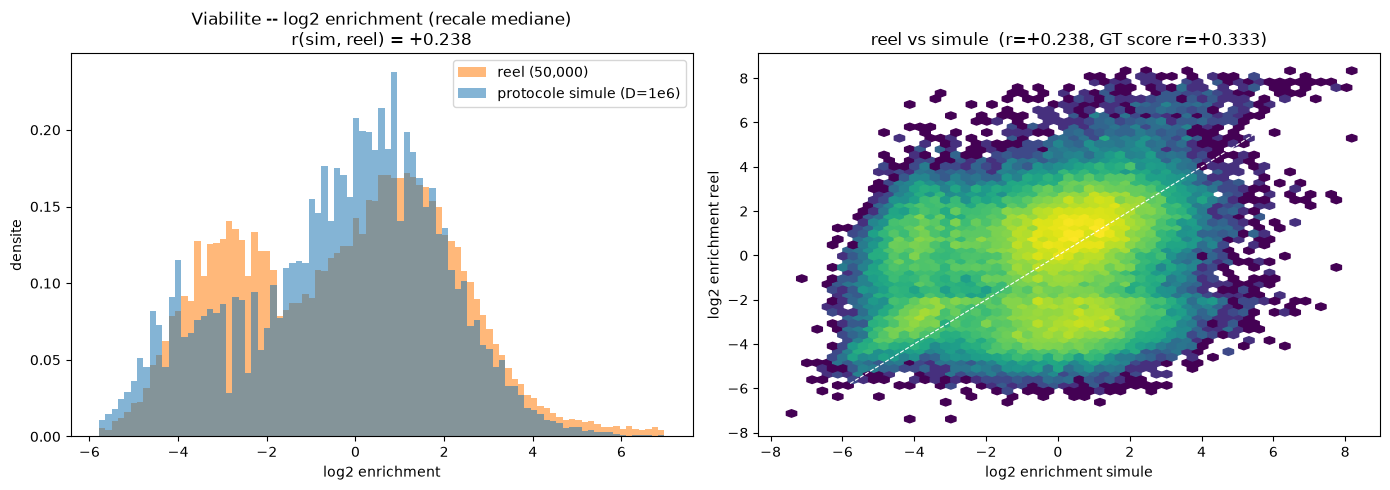


reel               n=  50,000  pics (find_peaks, prominence>=5%) : -3.36, -2.97, +1.16
simule (D=1e6)     n=  50,000  pics (find_peaks, prominence>=5%) : -4.12, -3.53, -1.95, -0.97, -0.57, +0.21, +1.00

accord replicat-replicat (simule) :
  rep0 vs rep1 : +0.558
  rep0 vs rep2 : +0.558
  rep1 vs rep2 : +0.560


In [10]:
def center(x):
    x = np.asarray(x, np.float64)
    return x - np.median(x[np.isfinite(x)])

sim_viab = sims[0]["sim_viab"]
rv, sv = center(y_viab), center(sim_viab)
mfin = np.isfinite(rv) & np.isfinite(sv)
r_viab_sim = pearson(rv[mfin], sv[mfin])
print(f"r(sim_viab, reel viab) = {r_viab_sim:+.3f}   (n={mfin.sum():,}, GT score r={r_viab_gt:+.3f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lo, hi = np.percentile(np.concatenate([rv[mfin], sv[mfin]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
axes[0].hist(rv[mfin], bins=bins, density=True, alpha=0.55, color="tab:orange", label=f"reel ({mfin.sum():,})")
axes[0].hist(sv[mfin], bins=bins, density=True, alpha=0.55, color="tab:blue",   label="protocole simule (D=1e6)")
axes[0].set(title=f"Viabilite -- log2 enrichment (recale mediane)\nr(sim, reel) = {r_viab_sim:+.3f}",
            xlabel="log2 enrichment", ylabel="densite"); axes[0].legend()

axes[1].hexbin(sv[mfin], rv[mfin], gridsize=55, bins="log", cmap="viridis", mincnt=1)
d = [max(sv[mfin].min(), lo), min(sv[mfin].max(), hi)]
axes[1].plot(d, d, "w--", lw=0.8)
axes[1].set(title=f"reel vs simule  (r={r_viab_sim:+.3f}, GT score r={r_viab_gt:+.3f})",
            xlabel="log2 enrichment simule", ylabel="log2 enrichment reel")
plt.tight_layout(); plt.show()

print()
for label, arr in [("reel", rv[mfin]), ("simule (D=1e6)", sv[mfin])]:
    counts, edges = np.histogram(arr, bins=80)
    peaks, _ = find_peaks(counts, prominence=counts.max() * 0.05)
    centers = [(edges[k] + edges[k + 1]) / 2 for k in peaks]
    print(f"{label:<18s} n={arr.size:>8,}  pics (find_peaks, prominence>=5%) : "
          + ", ".join(f"{c:+.2f}" for c in centers))

print()
print("accord replicat-replicat (simule) :")
for i, j in [(0, 1), (0, 2), (1, 2)]:
    a, b = center(sims[i]["sim_viab"]), center(sims[j]["sim_viab"])
    mm = np.isfinite(a) & np.isfinite(b)
    print(f"  rep{i} vs rep{j} : {pearson(a[mm], b[mm]):+.3f}")

### 5b. Dithering -- la fragmentation vient-elle du faible `D`, pas du modele ?

`D=1e6` donne `D/d0=20` reads/variant en moyenne -- les comptages NGS SIMULES (`lambda0p`/
`lambda2p`, tires Multinomial) sont donc eux-memes de petits entiers, exactement le mecanisme de
discretisation diagnostique sur les VRAIS comptages dans `AAV5_viab_sorting.ipynb` (sauf que le
quantum est ici 1, pas 0.5, puisque `Multinomial()` tire des entiers). Meme remede : bruit
`Uniform` de la taille du quantum avant de recalculer le ratio (reel : quantum 0.5 -> +-0.25 ;
simule : quantum 1 -> +-0.5), uniquement pour juger de la vraie forme (bimodale ou pas), sans
toucher aux comptages reels utilises ailleurs.

r(sim_viab ditheree, reel viab dithere) = +0.231   (brut, sans dithering : +0.238)


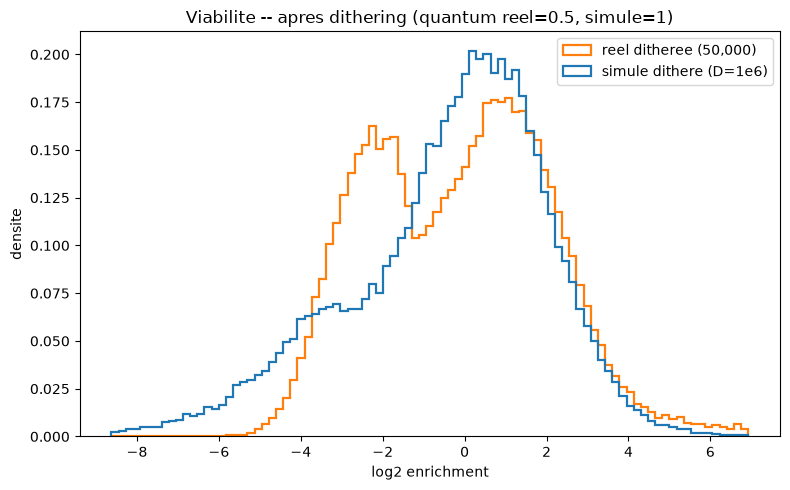


reel dithere       n=  50,000  pics : -2.28, +0.70
simule dithere     n=  50,000  pics : +0.49


In [11]:
def dither(x, half_width, seed):
    rng = np.random.default_rng(seed)
    return x + rng.uniform(-half_width, half_width, size=x.shape)

real_p = df["compte_plasmide"].to_numpy(np.float64)
real_v = df["compte_virus"].to_numpy(np.float64)
y_viab_d = np.log2((dither(real_v, 0.25, 10) + EPS) / (dither(real_p, 0.25, 11) + EPS))

l0p, l2p = sims[0]["l0p"], sims[0]["l2p"]
sim_viab_d = np.log2((dither(l2p, 0.5, 20) + EPS) / (dither(l0p, 0.5, 21) + EPS))

rv_d, sv_d = center(y_viab_d), center(sim_viab_d)
mfin_d = np.isfinite(rv_d) & np.isfinite(sv_d)
r_viab_sim_d = pearson(rv_d[mfin_d], sv_d[mfin_d])
print(f"r(sim_viab ditheree, reel viab dithere) = {r_viab_sim_d:+.3f}   "
      f"(brut, sans dithering : {r_viab_sim:+.3f})")

fig, ax = plt.subplots(figsize=(8, 5))
lo, hi = np.percentile(np.concatenate([rv_d[mfin_d], sv_d[mfin_d]]), [0.2, 99.8])
bins = np.linspace(lo, hi, 90)
ax.hist(rv_d[mfin_d], bins=bins, density=True, histtype="step", lw=1.6, color="tab:orange",
        label=f"reel ditheree ({mfin_d.sum():,})")
ax.hist(sv_d[mfin_d], bins=bins, density=True, histtype="step", lw=1.6, color="tab:blue",
        label="simule dithere (D=1e6)")
ax.set(title="Viabilite -- apres dithering (quantum reel=0.5, simule=1)",
       xlabel="log2 enrichment", ylabel="densite"); ax.legend()
plt.tight_layout(); plt.show()

print()
for label, arr in [("reel dithere", rv_d[mfin_d]), ("simule dithere", sv_d[mfin_d])]:
    counts, edges = np.histogram(arr, bins=80)
    peaks, _ = find_peaks(counts, prominence=counts.max() * 0.05)
    centers = [(edges[k] + edges[k + 1]) / 2 for k in peaks]
    print(f"{label:<18s} n={arr.size:>8,}  pics : " + ", ".join(f"{c:+.2f}" for c in centers))

### 6. Population a travers le pipeline simule

In [12]:
p0 = sims[0]["p"]
lambdas_np = {
    "lambda0 (librairie = compte_plasmide reel)": np.asarray(p0.lambda0),
    "lambda0p (NGS plasmide simule)":             sims[0]["l0p"],
    "lambda2 (capsides)":                         np.asarray(p0.lambda2),
    "lambda2p (NGS virus simule)":                sims[0]["l2p"],
}
summary = pd.DataFrame({
    "total": [a.sum() for a in lambdas_np.values()],
    "n_variants (>=1)": [int((a >= 1).sum()) for a in lambdas_np.values()],
    "fraction_d0": [float((a >= 1).mean()) for a in lambdas_np.values()],
}, index=list(lambdas_np))
display(summary)
display(number_of_seq_threshold(lambdas_np, thresholds=[1, 10, 100, 1000]))

,total,n_variants (>=1),fraction_d0
lambda0 (librairie = compte_plasmide reel),1.356802e+11,50000,1.00000
lambda0p (NGS plasmide simule),1.000000e+06,49936,0.99872
lambda2 (capsides),3.580815e+10,50000,1.00000
lambda2p (NGS virus simule),1.000000e+06,41063,0.82126


,1.0,10.0,100.0,1000.0
lambda,,,,
lambda0 (librairie = compte_plasmide reel),50000,50000,50000,50000
lambda0p (NGS plasmide simule),49936,39125,86,0
lambda2 (capsides),50000,50000,49999,49993
lambda2p (NGS virus simule),41063,23894,933,35


### 7. Notes

- `D=1e6` calibre pour matcher le ratio reads/variant reel (~20-40 selon le CSV) a l'echelle
  reduite de ce sous-echantillon (`D/d0=20`) -- PAS le `D=1e8` repris d'AAV9 dans les notebooks
  `AAV5_SEL_fitting_protocol*.ipynb` precedents (qui donnait `D/d0=2000`, ~100x trop dense par
  rapport au reel).
- `F_sel=J_sel=0` : la phase selectivite n'est pas modelisee dans ce notebook, focus exclusif sur
  `lambda0 -> lambda1 -> lambda2 -> lambda2p`.
- `lambda0` calibre sur le VRAI `compte_plasmide` (pas un proxy comme `avg(org2,org3)`) -- possible
  ici uniquement parce que ce notebook travaille sur le CSV `viab` (qui a `compte_plasmide`, pas sur
  un sous-ensemble filtre par l'organoide).
- `rho`/`mu`/`T_viab`/`noise_viab`/`dilution_factor` repris tels quels du point de fonctionnement
  "classique" deja etabli pour AAV5 -- non recalibres dans ce notebook.